# Topological Transitions
## How does S&P 500 topology change approaching a crisis?

In Notebook 01 we established the topological baseline — compact point clouds, no persistent H1, Euler characteristic converging smoothly to 1.

This notebook documents how that baseline **breaks down** as the market approaches the 2008 Global Financial Crisis. We follow the methodology of **Gidea & Katz (2018)** exactly:

- Asset: S&P 500
- Embedding: Takens with $d = 10$
- Window: $w = 50$ days
- Crises: dot-com crash (2000) and GFC (2008)

The goal is a faithful reproduction of their results before extending and improving the methodology in later notebooks.

In [5]:
import sys
import os
sys.path.insert(0, os.path.expanduser('~/TDA-Gabo/tda-financial-data-pipeline'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import compute_log_returns, normalize
from src.embedding import takens_embedding
from src.data import fetch_ticker

# Load S&P 500

sp500 = fetch_ticker('^GSPC', '1995-01-01', '2024-01-01')
sp500.index = pd.to_datetime(sp500.index, utc=True).tz_localize(None)
sp500_r = normalize(compute_log_returns(sp500))

# Parameters — Gidea & Katz (2018)
d = 10   # embedding dimension
w = 50   # window size

print(f"S&P 500: {len(sp500_r)} days")
print(f"Parameters: d={d}, w={w} (Gidea & Katz 2018)")

Fetching ^GSPC from Yahoo Finance...
Cached to ../data/raw/GSPC_1995-01-01_2024-01-01.csv
S&P 500: 7299 days
Parameters: d=10, w=50 (Gidea & Katz 2018)


## Approaching the 2008 Crisis

We compute persistence diagrams at four key moments around the 2008 GFC — tracking how topology evolves from calm to crisis:

- **2006** — calm baseline (2 years before crisis)
- **2007** — pre-crisis buildup (1 year before)
- **Early 2008** — approaching crisis (6 months before)
- **Late 2008** — during crisis (Lehman bankruptcy: September 15, 2008)

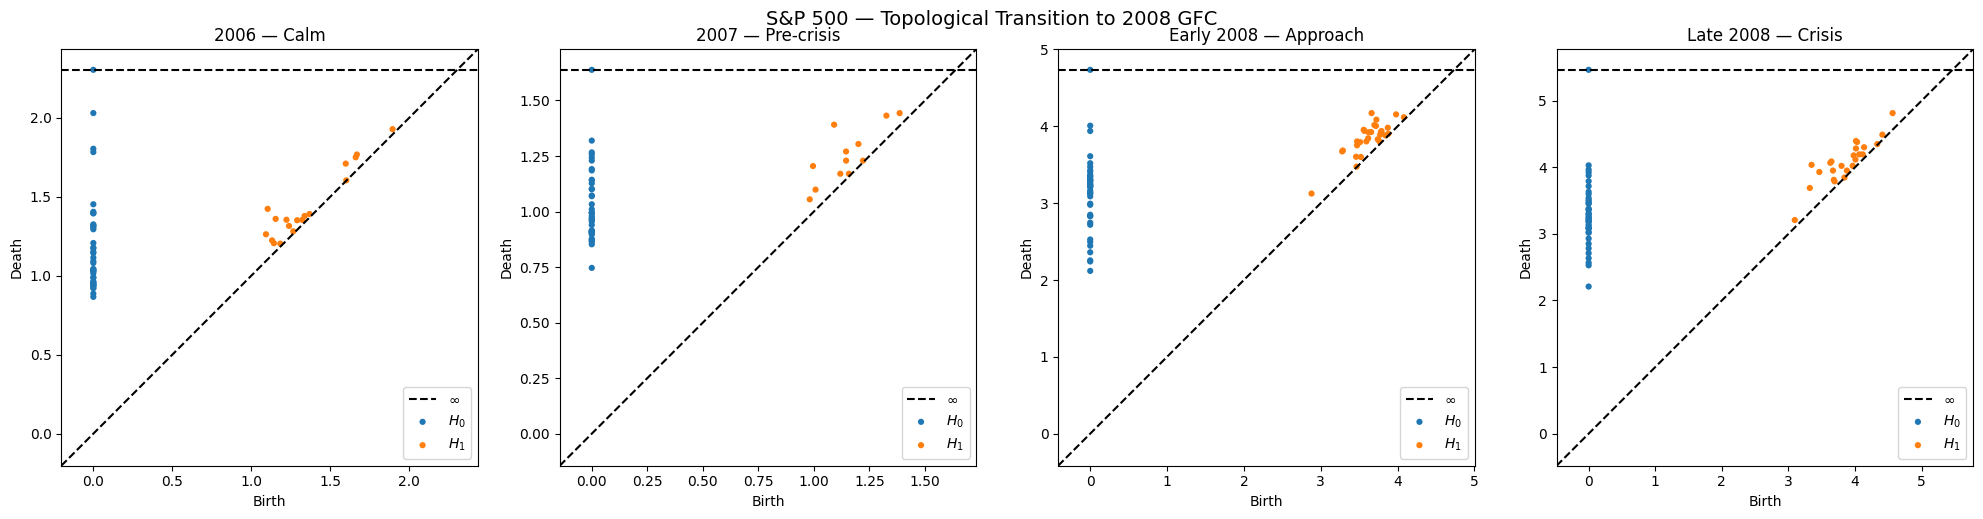

In [6]:
# Four snapshots approaching the 2008 crisis
snapshots = {
    '2006 — Calm':           '2006-01-01',
    '2007 — Pre-crisis':     '2007-01-01',
    'Early 2008 — Approach': '2008-03-01',
    'Late 2008 — Crisis':    '2008-09-15'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor='white')

for ax, (label, date) in zip(axes, snapshots.items()):
    # Extract window ending at this date
    idx = sp500_r.index.searchsorted(date)
    window = sp500_r.values[idx-w:idx]
    
    # Takens embedding
    X = takens_embedding(window, d)
    
    # Persistent homology
    diagrams = ripser(X)['dgms']
    
    # Plot
    plot_diagrams(diagrams, ax=ax, show=False)
    ax.set_title(label)
    ax.set_facecolor('white')

plt.suptitle('S&P 500 — Topological Transition to 2008 GFC', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Compute exact max H1 persistence for 2008 snapshots
print("2008 GFC — exact values:")
print(f"\n{'Period':<30} {'Scale':>10} {'Max H1':>10} {'H1 dots':>10}")
print("-" * 60)

for label, date in snapshots.items():
    idx = sp500_r.index.searchsorted(date)
    window = sp500_r.values[idx-w:idx]
    X = takens_embedding(window, d)
    diagrams = ripser(X)['dgms']
    
    h0 = diagrams[0]
    finite_h0 = h0[h0[:, 1] != np.inf]
    scale = finite_h0[:, 1].max() if len(finite_h0) > 0 else 0
    
    h1 = diagrams[1]
    finite_h1 = h1[h1[:, 1] != np.inf]
    max_h1 = (finite_h1[:, 1] - finite_h1[:, 0]).max() if len(finite_h1) > 0 else 0
    n_h1 = len(finite_h1)
    
    print(f"{label:<30} {scale:>10.4f} {max_h1:>10.4f} {n_h1:>10}")

2008 GFC — exact values:

Period                              Scale     Max H1    H1 dots
------------------------------------------------------------
2006 — Calm                        2.0294     0.3194         18
2007 — Pre-crisis                  1.3194     0.3000         12
Early 2008 — Approach              4.0081     0.5101         30
Late 2008 — Crisis                 4.0279     0.6890         24


## Observations — 2008 GFC

| Period | Filtration Scale | Max H1 Persistence | H1 Dots |
|--------|-----------------|-------------------|---------|
| 2006 — Calm | 2.03 | 0.32 | 18 |
| 2007 — Pre-crisis | 1.32 | 0.30 | 12 |
| Early 2008 — Approach | 4.01 | 0.51 | 30 |
| Late 2008 — Crisis | 4.03 | 0.69 | 24 |

Two signals tell different stories:

- **Filtration scale** — drops slightly in 2007, then jumps dramatically in early 2008. The transition is abrupt, not gradual.
- **H1 persistence** — relatively stable through 2006-2007, then increases steadily into the crisis.
- **H1 dots** — drops in 2007 then spikes to 30 in early 2008 — the approach is topologically the most complex moment.

Comparing with the dot-com crash: both show **H1 persistence as the more reliable monotonic indicator**. The filtration scale is sensitive to intermediate market events and can be misleading on its own.

## Approaching the 2000 Dot-com Crash

We repeat the analysis for the dot-com crash — the second crisis studied by Gidea & Katz (2018). This validates that the topological transition is not specific to the 2008 GFC.

- **1997** — calm baseline (3 years before crash)
- **1998** — pre-crisis (2 years before)
- **1999** — approaching crash (1 year before)
- **2000** — during crash (peak: March 10, 2000)

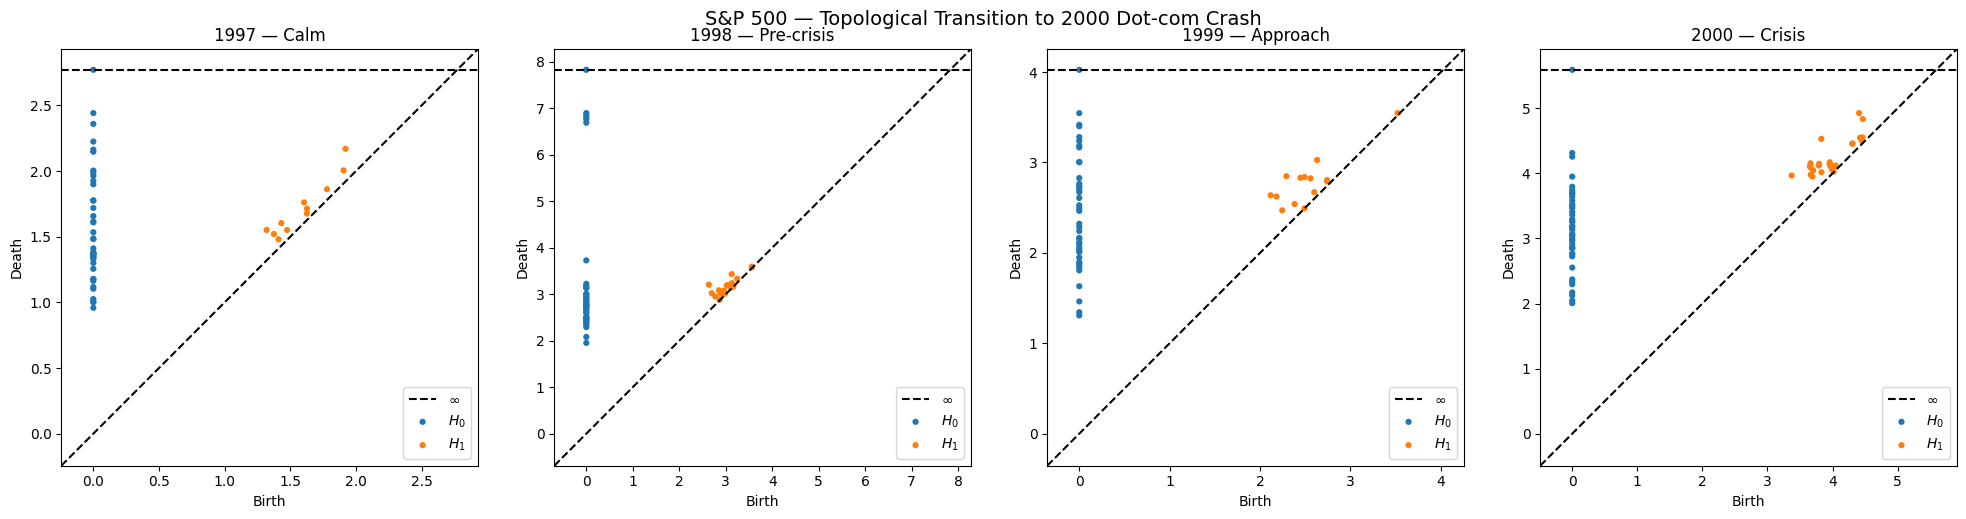

In [7]:
# Four snapshots approaching the 2000 dot-com crash
snapshots_dotcom = {
    '1997 — Calm':           '1997-01-01',
    '1998 — Pre-crisis':     '1998-01-01',
    '1999 — Approach':       '1999-01-01',
    '2000 — Crisis':         '2000-03-10'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor='white')

for ax, (label, date) in zip(axes, snapshots_dotcom.items()):
    idx = sp500_r.index.searchsorted(date)
    window = sp500_r.values[idx-w:idx]
    
    X = takens_embedding(window, d)
    diagrams = ripser(X)['dgms']
    
    plot_diagrams(diagrams, ax=ax, show=False)
    ax.set_title(label)
    ax.set_facecolor('white')

plt.suptitle('S&P 500 — Topological Transition to 2000 Dot-com Crash', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Compute exact max H1 persistence for each snapshot
print("Dot-com crash — exact values:")
print(f"\n{'Period':<25} {'Scale':>10} {'Max H1':>10} {'H1 dots':>10}")
print("-" * 55)

for label, date in snapshots_dotcom.items():
    idx = sp500_r.index.searchsorted(date)
    window = sp500_r.values[idx-w:idx]
    X = takens_embedding(window, d)
    diagrams = ripser(X)['dgms']
    
    # Filtration scale
    h0 = diagrams[0]
    finite_h0 = h0[h0[:, 1] != np.inf]
    scale = finite_h0[:, 1].max() if len(finite_h0) > 0 else 0
    
    # H1 features
    h1 = diagrams[1]
    finite_h1 = h1[h1[:, 1] != np.inf]
    max_h1 = (finite_h1[:, 1] - finite_h1[:, 0]).max() if len(finite_h1) > 0 else 0
    n_h1 = len(finite_h1)
    
    print(f"{label:<25} {scale:>10.4f} {max_h1:>10.4f} {n_h1:>10}")

Dot-com crash — exact values:

Period                         Scale     Max H1    H1 dots
-------------------------------------------------------
1997 — Calm                   2.4412     0.2491         11
1998 — Pre-crisis             6.8962     0.5695         21
1999 — Approach               3.5458     0.5562         14
2000 — Crisis                 4.3130     0.7019         25


## Observations — Dot-com Crash

| Period | Filtration Scale | Max H1 Persistence | H1 Dots |
|--------|-----------------|-------------------|---------|
| 1997 — Calm | 2.44 | 0.25 | 11 |
| 1998 — Pre-crisis | 6.90 | 0.57 | 21 |
| 1999 — Approach | 3.55 | 0.56 | 14 |
| 2000 — Crisis | 4.31 | 0.70 | 25 |

The dot-com crash exhibits two distinct signals:

- **Filtration scale** — non-monotonic, spikes in 1998 (LTCM crisis), drops in 1999, rises again in 2000
- **H1 persistence** — monotonically increasing throughout, from 0.25 to 0.70

This suggests that **H1 persistence is a more reliable transition indicator than filtration scale alone** — it captures the gradual topological buildup even when the overall scale fluctuates due to intermediate market events.

## Summary

The four snapshots per crisis give a first qualitative view of topological transitions:

**2008 GFC:**
- Filtration scale and H1 persistence jump abruptly in early 2008
- The transition concentrates in the 6 months before Lehman

**Dot-com 2000:**
- H1 persistence increases from 1997 to 2000
- Filtration scale spikes in 1998 due to the LTCM crisis, then rises again into 2000

These are static snapshots — a limited view. In Notebook 03 we track the full continuous evolution of topology using the $L^2$ norm of persistence landscapes, which will give a much richer picture of both transitions.